# Project 2: Fraud Detection - Step 1: Preprocessing

This notebook handles the data ingestion, train/val/test splitting, and scaling/outlier preparation for the financial transaction dataset.

## Blueprint Actions Covered
* **The Split**: Strict train/validation/test split performed immediately.
* **Missing Values & Outliers**: Imputation (median/mode) and outlier capping/flooring.
* **Scaling**: StandardScaler and MinMaxScaler execution.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

FRAUD_DATA = "../datasets/fraud/credit_card_fraud_10k.csv"
print(f"Fraud dataset exists: {os.path.exists(FRAUD_DATA)}")

Fraud dataset exists: True


## 1. Strict Stratified Train/Val/Test Split

To prevent any form of data leakage (cognitive or preprocessing), we immediately split our data into training (70%), validation (15%), and test (15%) partitions. Because financial fraud datasets are highly imbalanced, we use **stratified** splitting to maintain the proportion of fraud vs. non-fraud transactions across all splits.

In [2]:
# Load raw dataset
df = pd.read_csv(FRAUD_DATA)

# Separate features and target
X = df.drop(columns=['transaction_id', 'is_fraud'])
y = df['is_fraud']

# Perform Stratified Train (70%), Validation (15%), and Test (15%) splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train set shape:      {X_train.shape}, positive rate: {y_train.mean():.4%}")
print(f"Validation set shape: {X_val.shape}, positive rate: {y_val.mean():.4%}")
print(f"Test set shape:       {X_test.shape}, positive rate: {y_test.mean():.4%}")

Train set shape:      (7000, 8), positive rate: 1.5143%
Validation set shape: (1500, 8), positive rate: 1.5333%
Test set shape:       (1500, 8), positive rate: 1.4667%


## 2. Exploratory Data Analysis (EDA) on Training Split

We perform EDA exclusively on the training set to prevent cognitive leakage. We analyze distribution curves for key numerical features and examine categorical frequencies.

/tmp/ipykernel_289797/1107308924.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x='merchant_category', ax=axes[1, 1], palette='Set2')


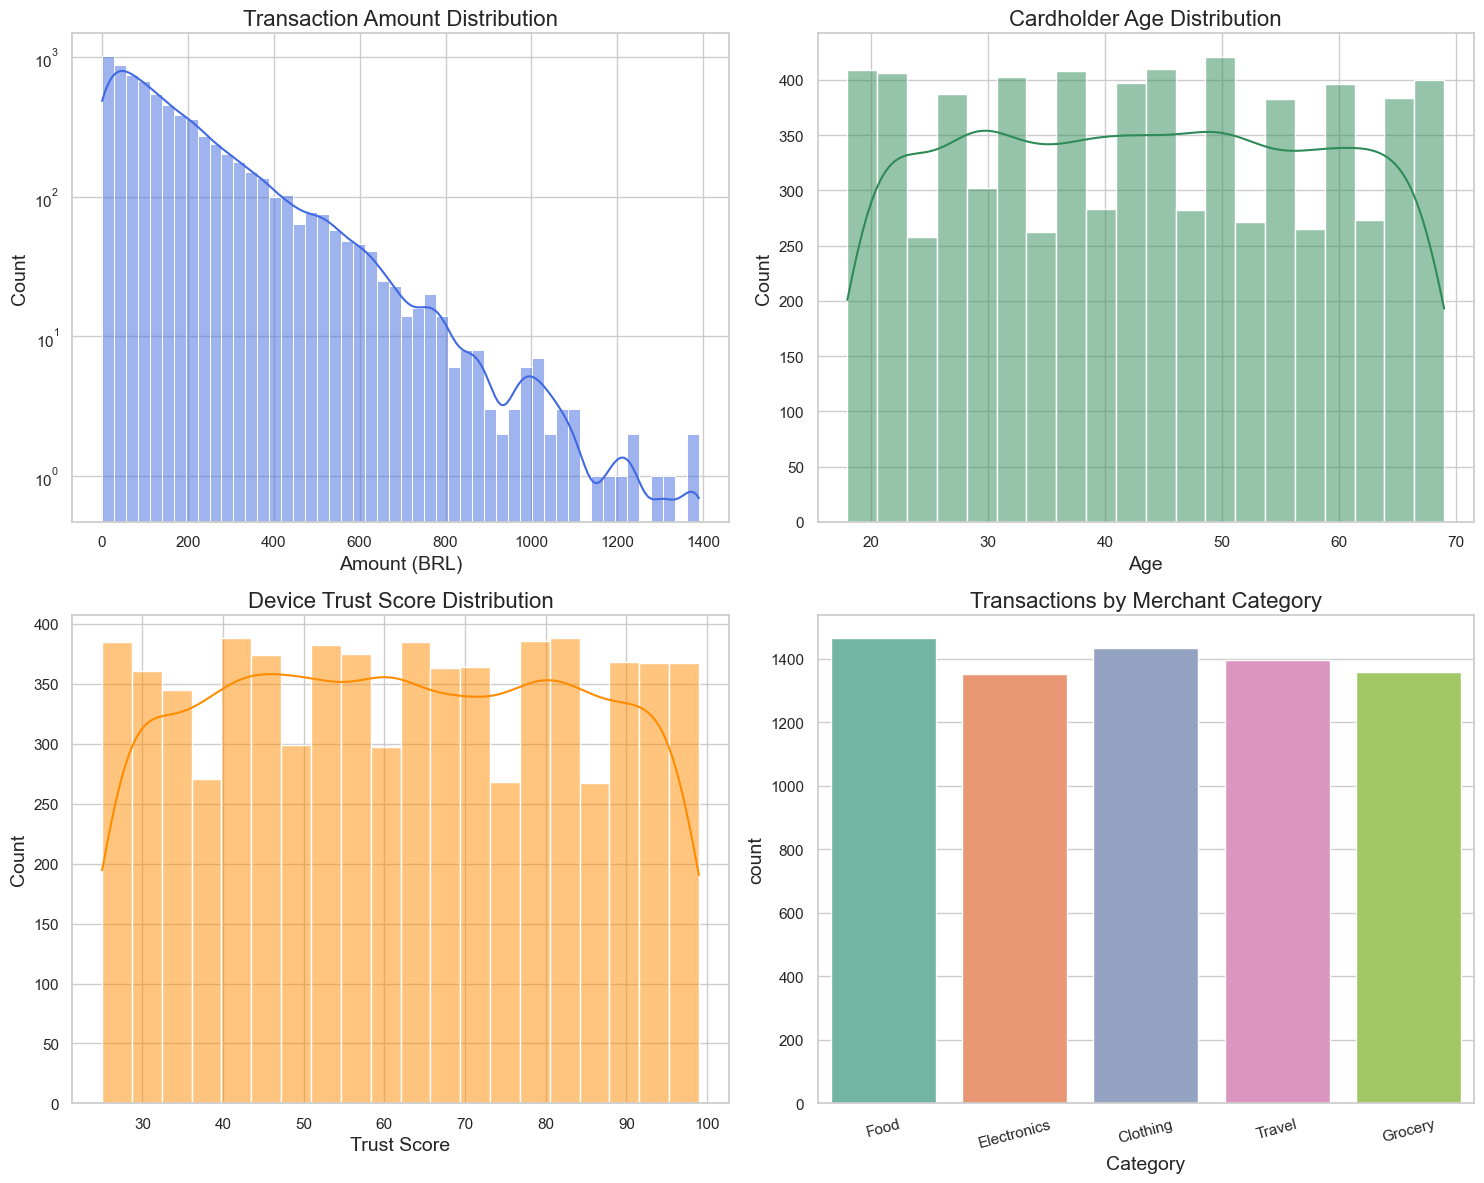

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# Create a visual grid of distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of Transaction Amounts (Log-scaled)
sns.histplot(X_train['amount'], bins=50, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Transaction Amount Distribution')
axes[0, 0].set_xlabel('Amount (BRL)')
axes[0, 0].set_yscale('log') # Log scale since amount is heavily skewed

# 2. Distribution of Cardholder Age
sns.histplot(X_train['cardholder_age'], bins=20, kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Cardholder Age Distribution')
axes[0, 1].set_xlabel('Age')

# 3. Distribution of Device Trust Score
sns.histplot(X_train['device_trust_score'], bins=20, kde=True, ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Device Trust Score Distribution')
axes[1, 0].set_xlabel('Trust Score')

# 4. Merchant Category counts
sns.countplot(data=X_train, x='merchant_category', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Transactions by Merchant Category')
axes[1, 1].set_xlabel('Category')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "numerical_categorical_distributions.png"), dpi=150)
plt.show()

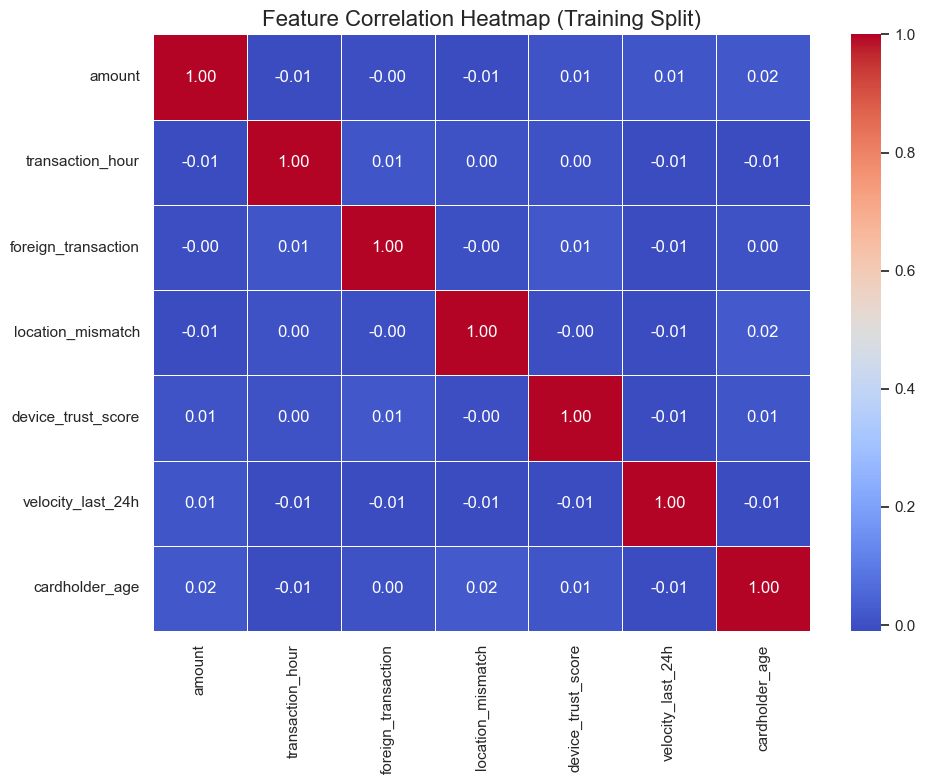

In [4]:
# Correlation heatmap
numerical_cols = ['amount', 'transaction_hour', 'foreign_transaction', 
                    'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap (Training Split)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "features_correlation_heatmap.png"), dpi=150)
plt.show()

## 3. Custom Outlier Capper Transformer

To handle extreme outliers robustly without dropping records (which is important for distance-based/anomaly-detection models), we write a custom Scikit-Learn transformer to clip values outside the 1st and 99th percentiles. The boundaries are calculated strictly on the training partition and applied uniformly to validation/test splits.

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Custom transformer to cap extreme outliers using percentiles (1st and 99th)
    fitted strictly on the training partition.
    """
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}
        
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            self.lower_bounds_[col] = X_df[col].quantile(self.lower_quantile)
            self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self
        
    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            X_df[col] = X_df[col].clip(lower=self.lower_bounds_[col], upper=self.upper_bounds_[col])
        return X_df.values

## 4. Pipeline Construction & Fitting

We build two variants of preprocessing pipelines:
1. **Standard Scaled Pipeline**: Scaled to zero mean and unit variance. Suitable for Isolation Forest, One-Class SVM, and LOF.
2. **Min-Max Scaled Pipeline**: Scaled between 0 and 1. Suitable for distance-sensitive neural network autoencoders.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Define feature groups
num_features = ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
bin_features = ['foreign_transaction', 'location_mismatch']
cat_features = ['merchant_category']

# 1. Pipeline for Standard Scaling
num_pipeline_std = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(lower_quantile=0.01, upper_quantile=0.99)),
    ('scaler', StandardScaler())
])

preprocessor_std = ColumnTransformer([
    ('num', num_pipeline_std, num_features),
    ('bin', SimpleImputer(strategy='most_frequent'), bin_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', sparse_output=False))
    ]), cat_features)
])

# 2. Pipeline for Min-Max Scaling
num_pipeline_mm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(lower_quantile=0.01, upper_quantile=0.99)),
    ('scaler', MinMaxScaler())
])

preprocessor_mm = ColumnTransformer([
    ('num', num_pipeline_mm, num_features),
    ('bin', SimpleImputer(strategy='most_frequent'), bin_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', sparse_output=False))
    ]), cat_features)
])

# Fit preprocessors strictly on training split
preprocessor_std.fit(X_train)
preprocessor_mm.fit(X_train)

print("Preprocessing pipelines fitted successfully.")

Preprocessing pipelines fitted successfully.


## 5. Splitting Transformation

In [7]:
# Extract transformed feature names
cat_encoder = preprocessor_std.named_transformers_['cat'].named_steps['ohe']
cat_cols_transformed = cat_encoder.get_feature_names_out(cat_features).tolist()
feature_names = num_features + bin_features + cat_cols_transformed

print(f"Total features after transformation: {len(feature_names)}")
print("Feature list:", feature_names)

# Transform splits
X_train_std = preprocessor_std.transform(X_train)
X_val_std = preprocessor_std.transform(X_val)
X_test_std = preprocessor_std.transform(X_test)

X_train_mm = preprocessor_mm.transform(X_train)
X_val_mm = preprocessor_mm.transform(X_val)
X_test_mm = preprocessor_mm.transform(X_test)

print(f"\nStandard Scaled Train shape: {X_train_std.shape}")
print(f"Standard Scaled Val shape:   {X_val_std.shape}")
print(f"Standard Scaled Test shape:  {X_test_std.shape}")

Total features after transformation: 11
Feature list: ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'foreign_transaction', 'location_mismatch', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']



Standard Scaled Train shape: (7000, 11)
Standard Scaled Val shape:   (1500, 11)
Standard Scaled Test shape:  (1500, 11)


## 6. Serialization & Target Persistence

In [8]:
import joblib

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

# Save scaled features to outputs/
pd.DataFrame(X_train_std, columns=feature_names).to_csv(os.path.join(OUTPUT_DIR, "train_scaled_std.csv"), index=False)
pd.DataFrame(X_val_std, columns=feature_names).to_csv(os.path.join(OUTPUT_DIR, "val_scaled_std.csv"), index=False)
pd.DataFrame(X_test_std, columns=feature_names).to_csv(os.path.join(OUTPUT_DIR, "test_scaled_std.csv"), index=False)

pd.DataFrame(X_train_mm, columns=feature_names).to_csv(os.path.join(OUTPUT_DIR, "train_scaled_mm.csv"), index=False)
pd.DataFrame(X_val_mm, columns=feature_names).to_csv(os.path.join(OUTPUT_DIR, "val_scaled_mm.csv"), index=False)
pd.DataFrame(X_test_mm, columns=feature_names).to_csv(os.path.join(OUTPUT_DIR, "test_scaled_mm.csv"), index=False)

# Save targets to outputs/
pd.DataFrame(y_train).to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
pd.DataFrame(y_val).to_csv(os.path.join(OUTPUT_DIR, "y_val.csv"), index=False)
pd.DataFrame(y_test).to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

# Serialize fitted preprocessors
preprocessors_params = {
    'preprocessor_std': preprocessor_std,
    'preprocessor_mm': preprocessor_mm,
    'feature_names': feature_names
}
joblib.dump(preprocessors_params, "models/preprocessor.joblib")

print("All preprocessed splits and pipelines serialized and exported successfully.")

All preprocessed splits and pipelines serialized and exported successfully.


## 7. Pipeline Output Verification

In [9]:
# Load standard scaled train set to verify columns and scaling distributions
train_check = pd.read_csv(os.path.join(OUTPUT_DIR, "train_scaled_std.csv"))
print("Loaded Standard Scaled Train shape:", train_check.shape)
print("\nFirst 5 rows:")
print(train_check.head())
print("\nNumerical stats (confirming zero mean and capping bounds):")
print(train_check[num_features].describe())

Loaded Standard Scaled Train shape: (7000, 11)

First 5 rows:
     amount  transaction_hour  device_trust_score  velocity_last_24h  \
0  0.839537          0.784508            0.744874          -0.708852   
1 -0.636745         -0.805404           -0.786983          -0.708852   
2 -0.910633          0.206358           -1.344022           1.407123   
3 -0.821826          1.507195           -0.276364           0.701798   
4 -0.076189          1.073583            0.976974           0.701798   

   cardholder_age  foreign_transaction  location_mismatch  \
0        0.175605                  0.0                0.0   
1        1.581826                  0.0                0.0   
2        0.041680                  0.0                0.0   
3       -0.226172                  1.0                0.0   
4       -1.431504                  1.0                0.0   

   merchant_category_Electronics  merchant_category_Food  \
0                            0.0                     1.0   
1                 